# Data Cleaning and Quality Checks

Quick look at the raw dataset before modelling. Checking for missing values, duplicates and basic distributional sanity.


In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

ROOT = Path.cwd()
raw_path = ROOT / "data" / "raw" / "synthetic_credit_customers.csv"
processed_path = ROOT / "data" / "processed" / "credit_risk_model_table.csv"

raw = pd.read_csv(raw_path)
model_table = pd.read_csv(processed_path)
raw.head()


,customer_id,statement_month,limit_balance,annual_income,sex,education,marital_status,age,utilization_ratio,payment_ratio,...,bill_amt_3,bill_amt_4,bill_amt_5,bill_amt_6,pay_amt_1,pay_amt_2,pay_amt_3,pay_amt_4,pay_amt_5,pay_amt_6
0,1,2025-02,113000.0,63036.0,male,university,married,21,0.3716,0.2661,...,46229.0,38918.0,50552.0,32090.0,13945.0,13945.0,14490.0,6159.0,7042.0,11461.0
1,2,2025-10,70000.0,62058.0,female,graduate,married,61,0.1381,0.3389,...,7381.0,9152.0,11250.0,11783.0,2056.0,3954.0,2305.0,1787.0,4163.0,5396.0
2,3,2025-08,27000.0,18429.0,male,graduate,single,36,0.5147,0.2914,...,12317.0,15799.0,14704.0,14861.0,1775.0,1788.0,5880.0,7837.0,4896.0,2125.0
3,4,2025-06,89000.0,42646.0,male,university,single,41,0.7118,0.3105,...,56342.0,63841.0,69438.0,62006.0,23647.0,21726.0,20017.0,14198.0,24489.0,13953.0
4,5,2025-06,54000.0,40918.0,female,high_school,married,24,0.7712,0.2494,...,46339.0,39556.0,42860.0,34501.0,12282.0,8830.0,12539.0,15382.0,6490.0,6803.0


In [2]:
quality_checks = pd.DataFrame({
    "check": ["rows", "columns", "missing_values", "duplicate_customer_ids", "observed_default_rate"],
    "value": [
        len(raw),
        raw.shape[1],
        raw.isna().sum().sum(),
        raw["customer_id"].duplicated().sum(),
        raw["default_next_month"].mean(),
    ],
})
quality_checks


,check,value
0,rows,3200.000000
1,columns,30.000000
2,missing_values,0.000000
3,duplicate_customer_ids,0.000000
4,observed_default_rate,0.131562


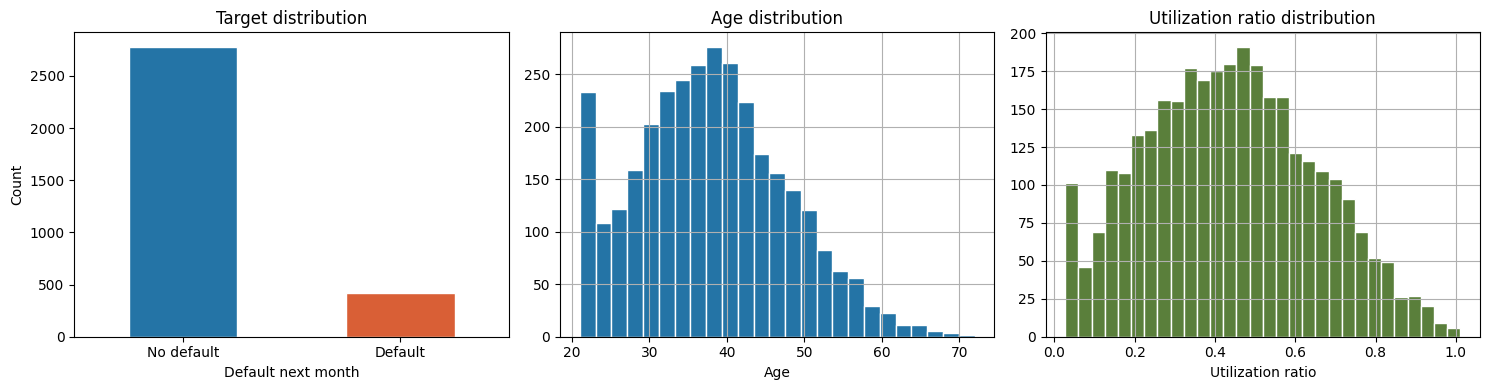

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

raw["default_next_month"].value_counts().sort_index().plot.bar(
    ax=axes[0], color=["#2474a6", "#d95f36"], edgecolor="white"
)
axes[0].set_title("Target distribution")
axes[0].set_xlabel("Default next month")
axes[0].set_ylabel("Count")
axes[0].set_xticklabels(["No default", "Default"], rotation=0)

raw["age"].hist(bins=25, ax=axes[1], color="#2474a6", edgecolor="white")
axes[1].set_title("Age distribution")
axes[1].set_xlabel("Age")

raw["utilization_ratio"].hist(bins=30, ax=axes[2], color="#5a7f3b", edgecolor="white")
axes[2].set_title("Utilization ratio distribution")
axes[2].set_xlabel("Utilization ratio")

plt.tight_layout()
plt.show()


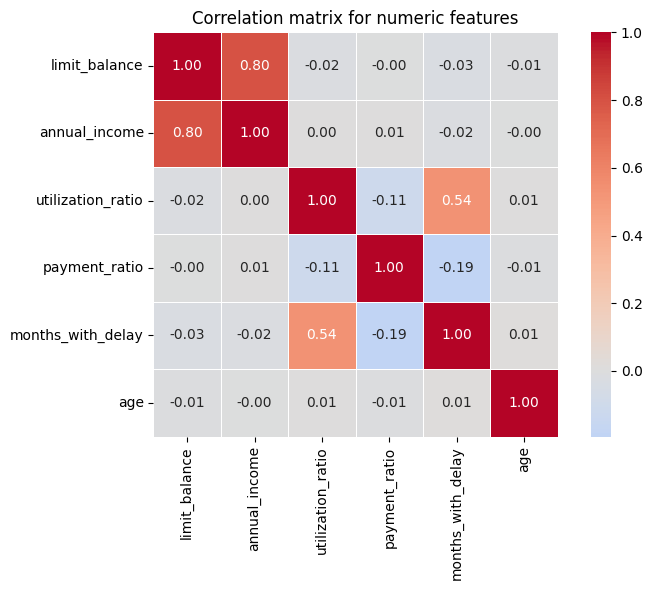

In [4]:
numeric_cols = [
    "limit_balance", "annual_income", "utilization_ratio",
    "payment_ratio", "months_with_delay", "age",
]
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(
    raw[numeric_cols].corr(),
    annot=True, fmt=".2f", cmap="coolwarm", center=0,
    square=True, linewidths=0.5, ax=ax,
)
ax.set_title("Correlation matrix for numeric features")
plt.tight_layout()
plt.show()


No missing values and no duplicate IDs. The default rate is around 12 percent, so the classes are imbalanced but not extreme. Utilization and months with delay show the expected positive correlation.
